In [6]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import re

In [2]:


csv_path = Path("data/export_sensor_readings_*.csv")
df = pd.concat(map(pd.read_csv, Path("data").glob("export_sensor_readings_*.csv")))
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 162528 entries, 0 to 162527
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   firmware        162528 non-null  str   
 1   original_date   162528 non-null  str   
 2   original_time   162528 non-null  str   
 3   sensor_id       162528 non-null  str   
 4   sensor_meaning  162528 non-null  str   
 5   station_id      162528 non-null  str   
 6   value           162528 non-null  object
 7   id              162528 non-null  int64 
 8   ingested_at     162528 non-null  str   
 9   reading_ts      162528 non-null  str   
dtypes: int64(1), object(1), str(8)
memory usage: 12.4+ MB


/tmp/ipykernel_1175/2235102203.py:2: DtypeWarning: Columns (6: value) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat(map(pd.read_csv, Path("data").glob("export_sensor_readings_*.csv")))


In [3]:
df.head()

,firmware,original_date,original_time,sensor_id,sensor_meaning,station_id,value,id,ingested_at,reading_ts
0,'V8.72.3855','2025/06/17','000000','00AT','Air Temperature','BAIDOA_MOH',21.8,1,'2025-06-19T07:36:34.17157+00:00','2025-06-17T00:00:00+00:00'
1,'V8.72.3855','2025/06/16',230000,'00AT','Air Temperature','BAIDOA_MOH',22.6,2,'2025-06-19T07:36:34.17157+00:00','2025-06-16T23:00:00+00:00'
2,'V8.72.3855','2025/06/16',220000,'00AT','Air Temperature','BAIDOA_MOH',22.5,3,'2025-06-19T07:36:34.17157+00:00','2025-06-16T22:00:00+00:00'
3,'V8.72.3855','2025/06/16',210000,'00AT','Air Temperature','BAIDOA_MOH',22.8,4,'2025-06-19T07:36:34.17157+00:00','2025-06-16T21:00:00+00:00'
4,'V8.72.3855','2025/06/16',200000,'00AT','Air Temperature','BAIDOA_MOH',23.9,5,'2025-06-19T07:36:34.17157+00:00','2025-06-16T20:00:00+00:00'


In [4]:
sensor_df = df[["original_date", "original_time", "station_id", "sensor_id", "sensor_meaning", "value"]]
sensor_df.head()

,original_date,original_time,station_id,sensor_id,sensor_meaning,value
0,'2025/06/17','000000','BAIDOA_MOH','00AT','Air Temperature',21.8
1,'2025/06/16',230000,'BAIDOA_MOH','00AT','Air Temperature',22.6
2,'2025/06/16',220000,'BAIDOA_MOH','00AT','Air Temperature',22.5
3,'2025/06/16',210000,'BAIDOA_MOH','00AT','Air Temperature',22.8
4,'2025/06/16',200000,'BAIDOA_MOH','00AT','Air Temperature',23.9


In [5]:
station = sensor_df["station_id"].unique()
sensor_df.groupby(['station_id']).size()

station_id
'000000AWS2'      384
'BAIDOA_MOH'    86208
'MOHADM_AFG'    75936
dtype: int64

In [7]:



def create_station_datasets(dataframe):
    station_datasets = {}
    normalized_station_ids = dataframe["station_id"].astype(str).str.strip("'\"")

    for station_id in normalized_station_ids.dropna().unique():
        station_label = re.sub(r"[^A-Za-z0-9_]+", "_", station_id).strip("_")
        dataset_name = f"df_{station_label}"
        station_datasets[dataset_name] = dataframe[
            normalized_station_ids == station_id
        ].copy()

    return station_datasets


station_datasets = create_station_datasets(sensor_df)
{dataset_name: len(dataset) for dataset_name, dataset in station_datasets.items()}

{'df_BAIDOA_MOH': 86208, 'df_000000AWS2': 384, 'df_MOHADM_AFG': 75936}

In [8]:
sensor_df[sensor_df["station_id"] == "'MOHADM_AFG'"]

,original_date,original_time,station_id,sensor_id,sensor_meaning,value
10464,'2025/08/20',100000,'MOHADM_AFG','00AT','Air Temperature','---'
10465,'2025/08/20','090000','MOHADM_AFG','00AT','Air Temperature','---'
10466,'2025/08/20','080000','MOHADM_AFG','00AT','Air Temperature','---'
10467,'2025/08/20','070000','MOHADM_AFG','00AT','Air Temperature','---'
10468,'2025/08/20','060000','MOHADM_AFG','00AT','Air Temperature','---'
...,...,...,...,...,...,...
162427,'2026/09/20',170000,'MOHADM_AFG','SOLR','Solar Radiation',12956.6
162428,'2026/09/20',160000,'MOHADM_AFG','SOLR','Solar Radiation',22573.6
162429,'2026/09/20',150000,'MOHADM_AFG','SOLR','Solar Radiation',28793.8
162430,'2026/09/20',140000,'MOHADM_AFG','SOLR','Solar Radiation',36791.0


In [9]:
def remove_error_rows(source_df, error_df=None):
    normalized_values = source_df["value"].map(
        lambda value: value.strip("'\"")
        if isinstance(value, str)
        else value
    )
    numeric_values = pd.to_numeric(normalized_values, errors="coerce")
    error_mask = normalized_values.eq("---") | numeric_values.eq(-999)
    removed_rows = source_df.loc[error_mask].copy()
    cleaned_source_df = source_df.loc[~error_mask].copy()

    if error_df is None:
        error_df = pd.DataFrame(columns=source_df.columns)

    error_df = pd.concat([error_df, removed_rows], ignore_index=True)
    return cleaned_source_df, error_df

In [10]:
error_df = None

for dataset_name, dataset in station_datasets.items():
    dataset, error_df = remove_error_rows(dataset, error_df)
    station_datasets[dataset_name] = dataset
    globals()[dataset_name] = dataset

{dataset_name: len(dataset) for dataset_name, dataset in station_datasets.items()} | {"error_df": len(error_df)}

{'df_BAIDOA_MOH': 85952,
 'df_000000AWS2': 2,
 'df_MOHADM_AFG': 75177,
 'error_df': 1397}

In [12]:
def remove_quotes(dataframe):
    cleaned_dataframe = dataframe.copy()

    for column in cleaned_dataframe.columns:
        cleaned_dataframe[column] = cleaned_dataframe[column].map(
            lambda value: value.strip("'\"")
            if isinstance(value, str)
            else value
        )

    return cleaned_dataframe


def clean_dataframe(dataframe):
    cleaned_dataframe = dataframe.copy()

    if "original_date" in cleaned_dataframe.columns:
        cleaned_dataframe["original_date"] = pd.to_datetime(
            cleaned_dataframe["original_date"],
            format="%Y/%m/%d",
            errors="coerce",
        )

    if "value" in cleaned_dataframe.columns:
        cleaned_dataframe["value"] = pd.to_numeric(
            cleaned_dataframe["value"],
            errors="coerce",
        )

    return cleaned_dataframe


for dataset_name, dataset in station_datasets.items():
    dataset_without_quotes = remove_quotes(dataset)
    cleaned_dataset = clean_dataframe(dataset_without_quotes)
    station_datasets[dataset_name] = cleaned_dataset
    globals()[dataset_name] = cleaned_dataset
    print(dataset_name)
    display(cleaned_dataset.head())

df_BAIDOA_MOH


,original_date,original_time,station_id,sensor_id,sensor_meaning,value
0,2025-06-17,000000,BAIDOA_MOH,00AT,Air Temperature,21.8
1,2025-06-16,230000,BAIDOA_MOH,00AT,Air Temperature,22.6
2,2025-06-16,220000,BAIDOA_MOH,00AT,Air Temperature,22.5
3,2025-06-16,210000,BAIDOA_MOH,00AT,Air Temperature,22.8
4,2025-06-16,200000,BAIDOA_MOH,00AT,Air Temperature,23.9


df_000000AWS2


,original_date,original_time,station_id,sensor_id,sensor_meaning,value
9588,2025-08-13,100000,000000AWS2,SOLR,Solar Radiation,0.0
9780,2025-08-13,100000,000000AWS2,SOLR,Solar Radiation,0.0


df_MOHADM_AFG


,original_date,original_time,station_id,sensor_id,sensor_meaning,value
10836,2025-08-20,110000,MOHADM_AFG,SOLR,Solar Radiation,0.00
10932,2025-08-20,110000,MOHADM_AFG,SOLR,Solar Radiation,0.00
11028,2025-08-20,110000,MOHADM_AFG,SOLR,Solar Radiation,0.00
11124,2025-08-20,110000,MOHADM_AFG,SOLR,Solar Radiation,0.00
11952,2025-08-20,120000,MOHADM_AFG,RAIN,Rainfall,0.01


In [13]:
def show_sensor_pairs(dataframe):
    display(
        dataframe[["sensor_id", "sensor_meaning"]]
        .drop_duplicates()
        .sort_values(["sensor_id", "sensor_meaning"])
        .reset_index(drop=True)
    )


show_sensor_pairs(df)

,sensor_id,sensor_meaning
0,'00AP','Atmospheric Pressure'
1,'00AT','Air Temperature'
2,'00DP','Dew Point'
3,'00RH','Relative Humidity'
4,'00WD','Wind Direction'
5,'00WS','Wind Speed'
6,'RAIN','Rainfall'
7,'SOLR','Solar Radiation'


In [14]:
def pivot_sensor_values(dataframe):
    return (
        dataframe.pivot_table(
            index=["original_date", "original_time"],
            columns="sensor_id",
            values="value",
            aggfunc="first",
        )
        .reset_index()
        .rename_axis(columns=None)
    )


df_BAIDOA_MOH_pivot = pivot_sensor_values(df_BAIDOA_MOH)
df_BAIDOA_MOH_pivot.head()

,original_date,original_time,00AP,00AT,00DP,00RH,00WD,00WS,RAIN,SOLR
0,2025-06-16,140000,NaN,NaN,NaN,NaN,127.0,1.0,0.0,28.8
1,2025-06-16,150000,962.0,29.5,18.4,51.4,271.9,1.2,0.0,1316.8
2,2025-06-16,160000,961.9,29.1,18.5,52.8,261.1,0.5,0.0,3157.3
3,2025-06-16,170000,961.3,29.1,18.5,53.1,174.7,3.1,0.0,3040.5
4,2025-06-16,180000,961.8,27.5,19.5,62.1,122.8,3.7,0.0,3680.5


In [15]:
len(df_BAIDOA_MOH_pivot)

10727

In [16]:
df_BAIDOA_MOH_wndw = df_BAIDOA_MOH_pivot.copy()
df_BAIDOA_MOH_wndw["WNDW"] = (
    df_BAIDOA_MOH_wndw["00WD"] * df_BAIDOA_MOH_wndw["00WS"]
)
df_BAIDOA_MOH_wndw = df_BAIDOA_MOH_wndw.drop(columns=["00WD", "00WS"])
df_BAIDOA_MOH_wndw.head()

,original_date,original_time,00AP,00AT,00DP,00RH,RAIN,SOLR,WNDW
0,2025-06-16,140000,NaN,NaN,NaN,NaN,0.0,28.8,127.00
1,2025-06-16,150000,962.0,29.5,18.4,51.4,0.0,1316.8,326.28
2,2025-06-16,160000,961.9,29.1,18.5,52.8,0.0,3157.3,130.55
3,2025-06-16,170000,961.3,29.1,18.5,53.1,0.0,3040.5,541.57
4,2025-06-16,180000,961.8,27.5,19.5,62.1,0.0,3680.5,454.36


In [17]:


def aggregate_sensor_values_by_day(dataframe):
    daily_dataframe = dataframe.copy()
    daily_dataframe["original_date"] = pd.to_datetime(
        daily_dataframe["original_date"],
        errors="coerce",
    ).dt.normalize()

    sensor_columns = [
        "00AP",
        "00AT",
        "00DP",
        "00RH",
        "00WD",
        "00WS",
        "RAIN",
        "SOLR",
    ]
    sensor_columns = [
        column for column in sensor_columns if column in daily_dataframe.columns
    ]

    daily_dataframe[sensor_columns] = daily_dataframe[sensor_columns].apply(
        pd.to_numeric,
        errors="coerce",
    )

    aggregation_rules = {
        "00AP": "mean",
        "00AT": "mean",
        "00DP": "mean",
        "00RH": "mean",
        "00WD": "circular_mean",
        "00WS": "mean",
        "RAIN": "sum",
        "SOLR": "sum",
    }

    def circular_mean(values):
        radians = pd.Series(values).dropna().to_numpy() * np.pi / 180
        if len(radians) == 0:
            return np.nan
        angle = np.degrees(
            np.arctan2(np.sin(radians).mean(), np.cos(radians).mean())
        ) % 360
        return 0.0 if np.isclose(angle, 360.0) else angle

    aggregated = {}
    for column in sensor_columns:
        rule = aggregation_rules.get(column, "mean")
        aggregation_function = (
            circular_mean if rule == "circular_mean" else rule
        )
        aggregated[column] = daily_dataframe.groupby("original_date")[column].agg(
            aggregation_function
        )

    return pd.DataFrame(aggregated).reset_index()


df_BAIDOA_MOH_daily = aggregate_sensor_values_by_day(df_BAIDOA_MOH_pivot)
df_BAIDOA_MOH_daily.head()

,original_date,00AP,00AT,00DP,00RH,00WD,00WS,RAIN,SOLR
0,2025-06-16,963.000000,25.744444,19.466667,70.022222,170.384257,1.800000,0.00,11383.0
1,2025-06-17,963.941667,23.266667,19.966667,82.570833,162.021242,1.679167,0.15,249541.2
2,2025-06-18,963.541667,24.841667,19.983333,75.904167,175.247180,1.895833,0.08,257073.2
3,2025-06-19,963.625000,25.383333,19.220833,70.416667,168.097075,1.766667,0.01,276580.0
4,2025-06-20,963.500000,25.495833,18.687500,68.454167,166.101610,2.112500,0.06,278404.6


In [18]:



def aggregate_sensor_values_by_day_with_weighted_wind(dataframe):
    daily_dataframe = dataframe.copy()
    daily_dataframe["original_date"] = pd.to_datetime(
        daily_dataframe["original_date"],
        errors="coerce",
    ).dt.normalize()

    sensor_columns = [
        "00AP",
        "00AT",
        "00DP",
        "00RH",
        "WNDW",
        "RAIN",
        "SOLR",
    ]
    sensor_columns = [
        column for column in sensor_columns if column in daily_dataframe.columns
    ]

    daily_dataframe[sensor_columns] = daily_dataframe[sensor_columns].apply(
        pd.to_numeric,
        errors="coerce",
    )

    aggregation_rules = {
        "00AP": "mean",
        "00AT": "mean",
        "00DP": "mean",
        "00RH": "mean",
        "WNDW": "circular_mean",
        "RAIN": "sum",
        "SOLR": "sum",
    }

    def circular_mean(values):
        radians = pd.Series(values).dropna().to_numpy() * np.pi / 180
        if len(radians) == 0:
            return np.nan
        angle = np.degrees(
            np.arctan2(np.sin(radians).mean(), np.cos(radians).mean())
        ) % 360
        return 0.0 if np.isclose(angle, 360.0) else angle

    aggregated = {}
    for column in sensor_columns:
        rule = aggregation_rules.get(column, "mean")
        aggregation_function = circular_mean if rule == "circular_mean" else rule
        aggregated[column] = daily_dataframe.groupby("original_date")[column].agg(
            aggregation_function
        )

    return pd.DataFrame(aggregated).reset_index()


df_BAIDOA_MOH_wndw_daily = aggregate_sensor_values_by_day_with_weighted_wind(
    df_BAIDOA_MOH_wndw
)
df_BAIDOA_MOH_wndw_daily.head()

,original_date,00AP,00AT,00DP,00RH,WNDW,RAIN,SOLR
0,2025-06-16,963.000000,25.744444,19.466667,70.022222,162.954705,0.00,11383.0
1,2025-06-17,963.941667,23.266667,19.966667,82.570833,120.041469,0.15,249541.2
2,2025-06-18,963.541667,24.841667,19.983333,75.904167,144.363544,0.08,257073.2
3,2025-06-19,963.625000,25.383333,19.220833,70.416667,220.550561,0.01,276580.0
4,2025-06-20,963.500000,25.495833,18.687500,68.454167,90.822267,0.06,278404.6


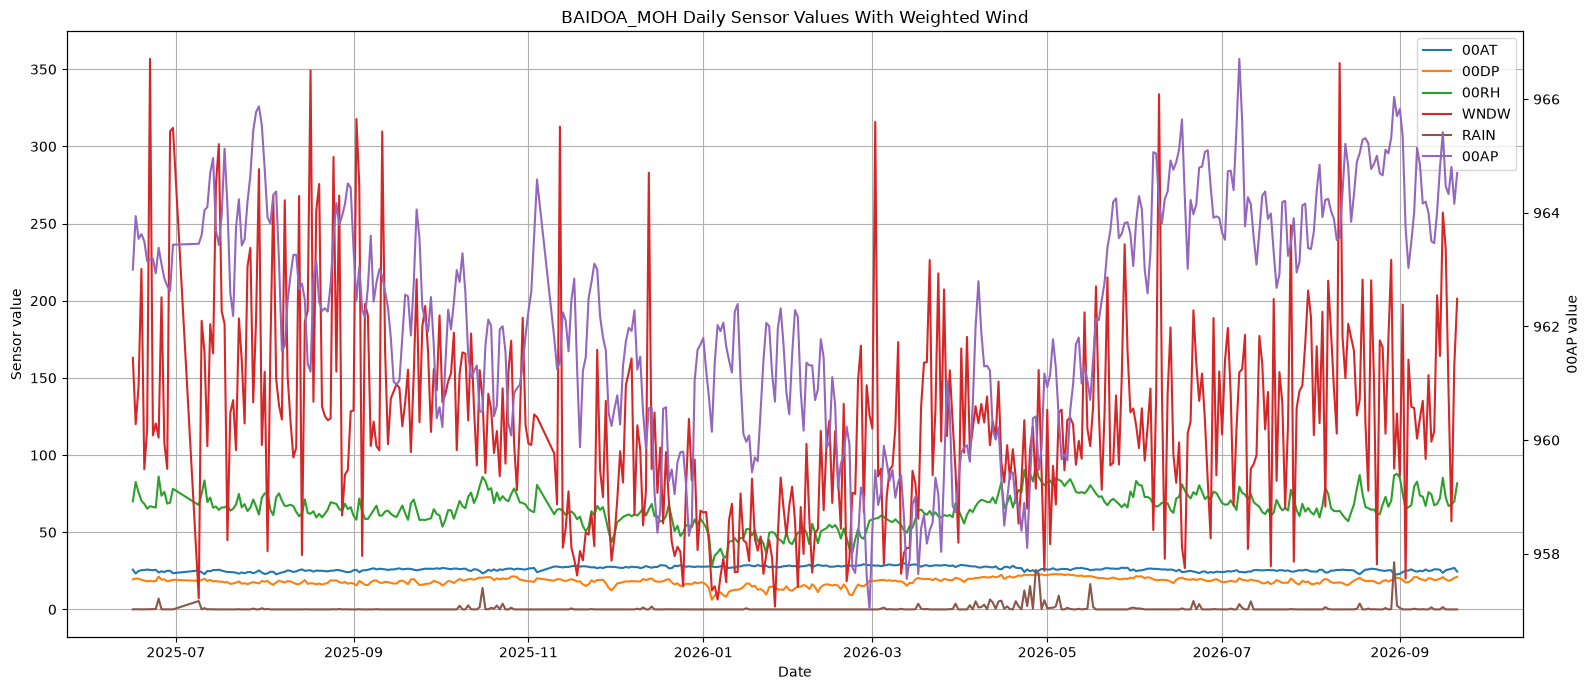

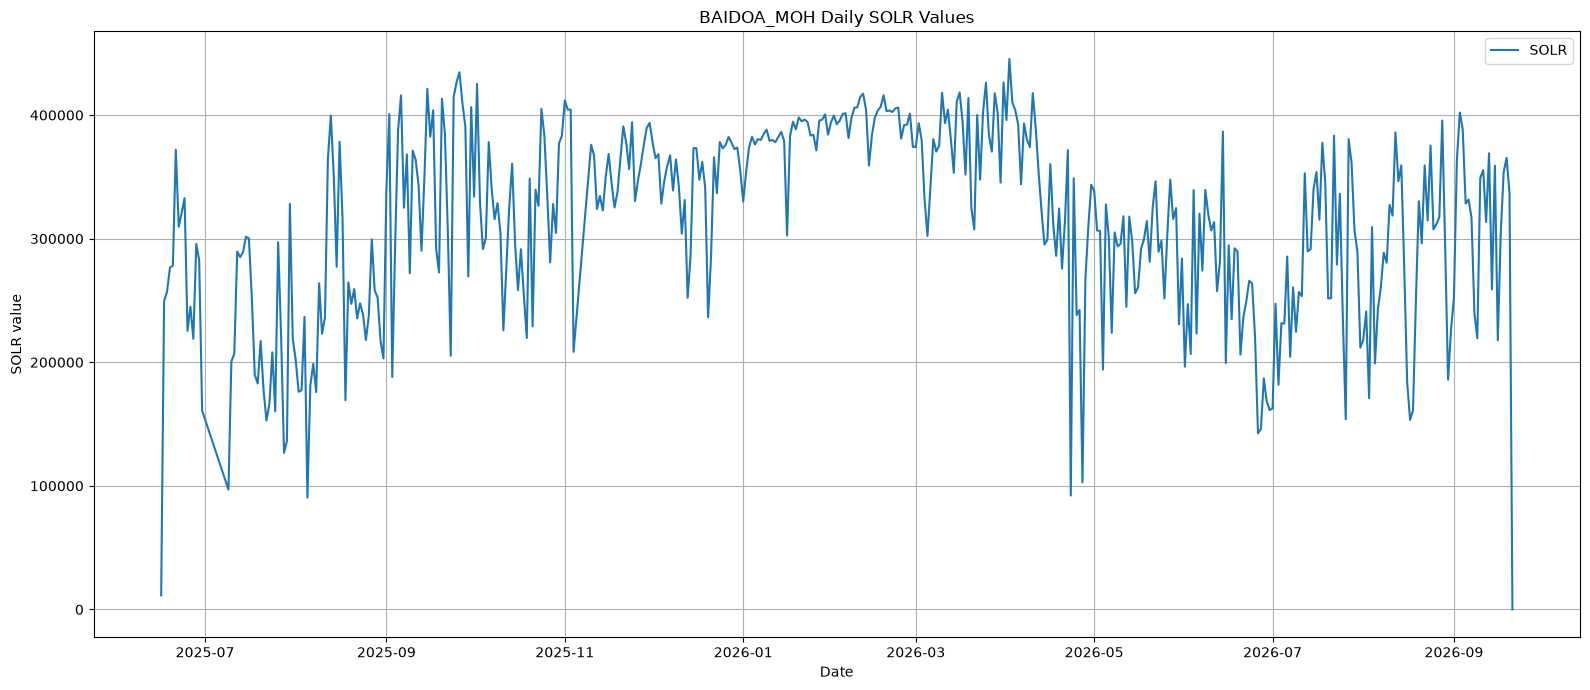

In [20]:
chart_data = df_BAIDOA_MOH_wndw_daily.copy()
chart_data["timestamp"] = chart_data["original_date"]
chart_data = chart_data.sort_values("timestamp")

sensor_columns = [
    column
    for column in chart_data.columns
    if column not in ["original_date", "timestamp", "SOLR", "00AP"]
]

fig, ax_left = plt.subplots(figsize=(16, 7))
ax_right = ax_left.twinx()

for sensor_column in sensor_columns:
    ax_left.plot(
        chart_data["timestamp"],
        chart_data[sensor_column],
        color="tab:brown" if sensor_column == "RAIN" else None,
        label=sensor_column,
        linestyle="-",
        marker=None,
    )

ax_right.plot(
    chart_data["timestamp"],
    chart_data["00AP"],
    color="tab:purple",
    label="00AP",
    linestyle="-",
    marker=None,
)

ax_left.set_title("BAIDOA_MOH Daily Sensor Values With Weighted Wind")
ax_left.set_xlabel("Date")
ax_left.set_ylabel("Sensor value")
ax_right.set_ylabel("00AP value")
ax_left.grid(True)

left_lines, left_labels = ax_left.get_legend_handles_labels()
right_lines, right_labels = ax_right.get_legend_handles_labels()
ax_left.legend(left_lines + right_lines, left_labels + right_labels)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(
    chart_data["timestamp"],
    chart_data["SOLR"],
    label="SOLR",
    linestyle="-",
    marker=None,
)
ax.set_title("BAIDOA_MOH Daily SOLR Values")
ax.set_xlabel("Date")
ax.set_ylabel("SOLR value")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
def calculate_column_correlations(dataframe):
    numeric_data = dataframe.select_dtypes(include="number")
    return numeric_data.corr()


calculate_column_correlations(df_BAIDOA_MOH_daily)

,00AP,00AT,00DP,00RH,00WD,00WS,RAIN,SOLR
00AP,1.000000,-0.730573,0.085867,0.360518,0.591459,0.191730,-0.070086,-0.488112
00AT,-0.730573,1.000000,-0.320096,-0.682043,-0.780708,-0.030193,-0.191601,0.747784
00DP,0.085867,-0.320096,1.000000,0.894454,0.516435,-0.148478,0.288427,-0.387177
00RH,0.360518,-0.682043,0.894454,1.000000,0.711985,-0.168468,0.362818,-0.620144
00WD,0.591459,-0.780708,0.516435,0.711985,1.000000,0.042345,0.203705,-0.570956
00WS,0.191730,-0.030193,-0.148478,-0.168468,0.042345,1.000000,-0.250940,-0.017682
RAIN,-0.070086,-0.191601,0.288427,0.362818,0.203705,-0.250940,1.000000,-0.212737
SOLR,-0.488112,0.747784,-0.387177,-0.620144,-0.570956,-0.017682,-0.212737,1.000000


In [22]:
calculate_column_correlations(df_BAIDOA_MOH_wndw_daily)

,00AP,00AT,00DP,00RH,WNDW,RAIN,SOLR
00AP,1.000000,-0.730573,0.085867,0.360518,0.288691,-0.070086,-0.488112
00AT,-0.730573,1.000000,-0.320096,-0.682043,-0.364561,-0.191601,0.747784
00DP,0.085867,-0.320096,1.000000,0.894454,0.245175,0.288427,-0.387177
00RH,0.360518,-0.682043,0.894454,1.000000,0.303390,0.362818,-0.620144
WNDW,0.288691,-0.364561,0.245175,0.303390,1.000000,-0.042809,-0.239689
RAIN,-0.070086,-0.191601,0.288427,0.362818,-0.042809,1.000000,-0.212737
SOLR,-0.488112,0.747784,-0.387177,-0.620144,-0.239689,-0.212737,1.000000


In [23]:
# Read CDI Data
csv_path = Path("data/export_all_cdi_alert_*.csv")
df_cdi = pd.concat(map(pd.read_csv, Path("data").glob("export_all_cdi_alert_*.csv")))
df_cdi.info()   

<class 'pandas.DataFrame'>
RangeIndex: 1504 entries, 0 to 1503
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   value      1504 non-null   float64
 1   district   1504 non-null   str    
 2   month      1504 non-null   str    
 3   region     1504 non-null   str    
 4   threshold  1504 non-null   str    
 5   year       1504 non-null   int64  
dtypes: float64(1), int64(1), str(4)
memory usage: 70.6 KB


In [24]:
df_cdi.groupby("district").size()

district
'Afgooye'          94
'Baraawe'          94
'Baydhaba'         94
'Buur Hakaba'      94
'Ceel Barde'       94
'Diinsoor'         94
'Kurtunwaarey'     94
'Marka'            94
'Qansax Dheere'    94
'Qoryooley'        94
'Rab Dhuure'       94
'Sablaale'         94
'Tayeeglow'        94
'Waajid'           94
'Wanla Weyn'       94
'Xudur'            94
dtype: int64

In [25]:
df_cdi_bai = df_cdi.loc[df_cdi["district"] == "'Baydhaba'"]
df_cdi_bai.head()

,value,district,month,region,threshold,year
470,0.752,'Baydhaba','03','Bay','Alarm',2026
471,0.967,'Baydhaba','05','Bay','Alert',2026
472,0.585,'Baydhaba','01','Bay','Alarm',2026
473,0.561,'Baydhaba','02','Bay','Alarm',2026
474,1.012,'Baydhaba','04','Bay','Normal',2026


In [26]:
df_cdi_bai = remove_quotes(df_cdi_bai)
df_cdi_bai.head()

,value,district,month,region,threshold,year
470,0.752,Baydhaba,03,Bay,Alarm,2026
471,0.967,Baydhaba,05,Bay,Alert,2026
472,0.585,Baydhaba,01,Bay,Alarm,2026
473,0.561,Baydhaba,02,Bay,Alarm,2026
474,1.012,Baydhaba,04,Bay,Normal,2026


In [33]:
df_cdi_bai.loc[df_cdi_bai["month"] == '10'].head()

,value,district,month,region,threshold,year
485,0.705,Baydhaba,10,Bay,Alarm,2025
494,0.911,Baydhaba,10,Bay,Alert,2024
502,1.022,Baydhaba,10,Bay,Normal,2023
518,0.680,Baydhaba,10,Bay,Alarm,2022
533,0.630,Baydhaba,10,Bay,Alarm,2021


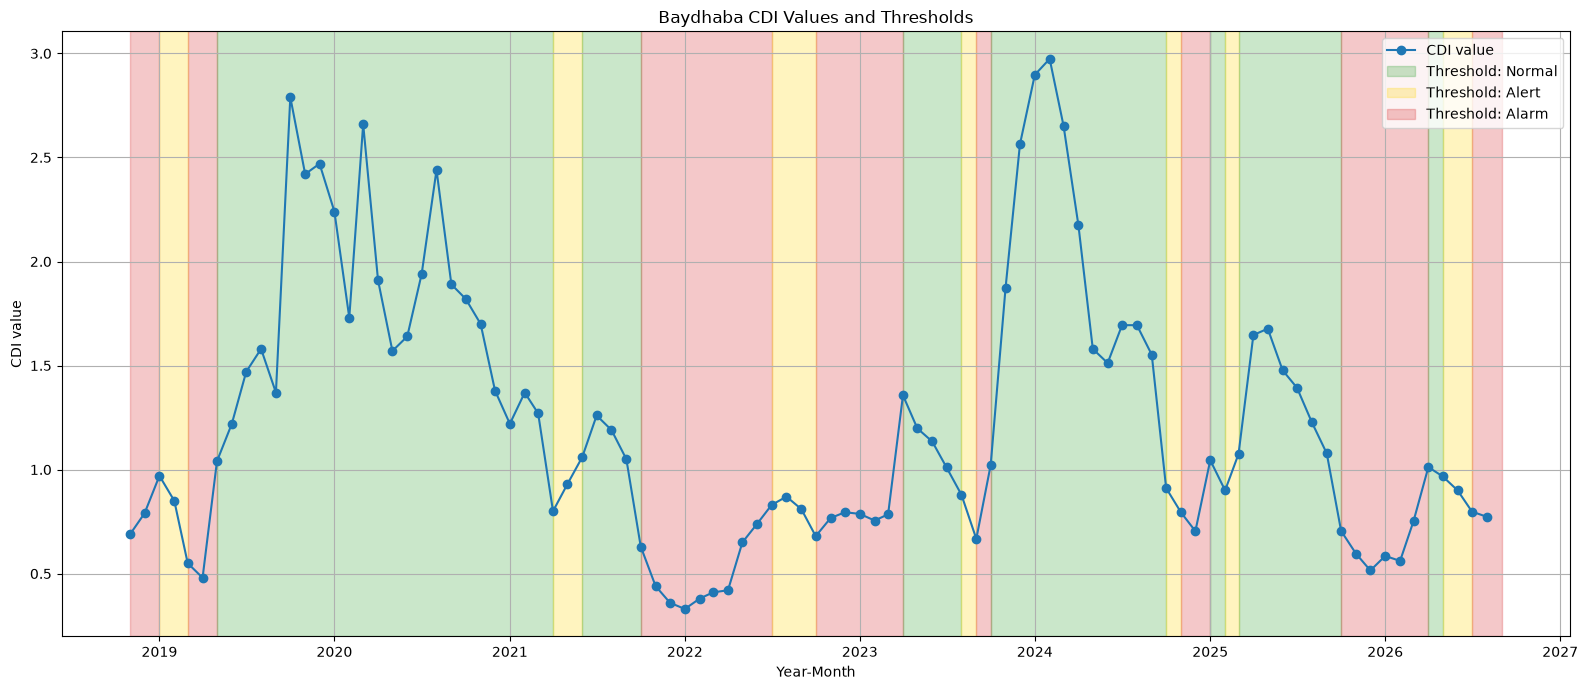

In [34]:


cdi_chart_data = df_cdi_bai.copy()
cdi_chart_data["year-month"] = pd.to_datetime(
    {
        "year": pd.to_numeric(cdi_chart_data["year"], errors="coerce"),
        "month": pd.to_numeric(cdi_chart_data["month"], errors="coerce"),
        "day": 1,
    },
    errors="coerce",
)
cdi_chart_data["value"] = pd.to_numeric(cdi_chart_data["value"], errors="coerce")
cdi_chart_data = cdi_chart_data.dropna(
    subset=["year-month", "value", "threshold"]
).sort_values("year-month")

threshold_colors = {
    "Normal": "tab:green",
    "Alert": "gold",
    "Alarm": "tab:red",
}
threshold_periods = cdi_chart_data["threshold"].ne(
    cdi_chart_data["threshold"].shift()
).cumsum()

fig, ax = plt.subplots(figsize=(16, 7))
for _, period_data in cdi_chart_data.groupby(threshold_periods):
    threshold = str(period_data["threshold"].iloc[0])
    start_date = period_data["year-month"].iloc[0]
    end_date = period_data["year-month"].iloc[-1] + pd.offsets.MonthBegin(1)
    ax.axvspan(
        start_date,
        end_date,
        color=threshold_colors[threshold],
        alpha=0.25,
    )

ax.plot(
    cdi_chart_data["year-month"],
    cdi_chart_data["value"],
    color="tab:blue",
    marker="o",
    label="CDI value",
)
ax.set_title("Baydhaba CDI Values and Thresholds")
ax.set_xlabel("Year-Month")
ax.set_ylabel("CDI value")
ax.grid(True)

threshold_legend = [
    Patch(color=color, alpha=0.25, label=f"Threshold: {threshold}")
    for threshold, color in threshold_colors.items()
]
value_line, value_label = ax.get_legend_handles_labels()
ax.legend(value_line + threshold_legend, value_label + [item.get_label() for item in threshold_legend])

plt.tight_layout()
plt.show()

In [35]:
# Read indicator data
csv_path = Path("data/export_indicator_data*.csv")
df_ind = pd.concat(map(pd.read_csv, Path("data").glob("export_indicator_data*.csv")))
df_ind.info()  
df_ind = remove_quotes(df_ind)
df_ind.head()

<class 'pandas.DataFrame'>
RangeIndex: 20784 entries, 0 to 20783
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   month       20784 non-null  str    
 1   id          20784 non-null  int64  
 2   value       20534 non-null  float64
 3   commodity   12832 non-null  str    
 4   district    20784 non-null  str    
 5   indicator   20784 non-null  str    
 6   region      20784 non-null  str    
 7   created_at  20784 non-null  str    
dtypes: float64(1), int64(1), str(6)
memory usage: 1.3 MB


,month,id,value,commodity,district,indicator,region,created_at
0,2018-11-01,2,0.38,NaN,Marka,cdi,Lower Shabelle,2024-01-11T13:05:40.159401+00:00
1,2018-11-01,3,0.48,NaN,Afgooye,cdi,Lower Shabelle,2024-01-11T13:05:40.159401+00:00
2,2018-11-01,4,0.28,NaN,Baraawe,cdi,Lower Shabelle,2024-01-11T13:05:40.159401+00:00
3,2018-11-01,5,0.35,NaN,Kurtunwaarey,cdi,Lower Shabelle,2024-01-11T13:05:40.159401+00:00
4,2018-11-01,6,0.38,NaN,Qoryooley,cdi,Lower Shabelle,2024-01-11T13:05:40.159401+00:00


In [36]:
df_ind.groupby('indicator').size()

indicator
cdi          1504
market      12832
ndvi         1488
rainfall     4960
dtype: int64

In [37]:
df_ind_bai = df_ind.loc[df_ind['district'] == 'Baydhaba'].drop(columns=['id', 'commodity', 'created_at'])
df_ind_bai.head()

,month,value,district,indicator,region
7,2018-11-01,0.69,Baydhaba,cdi,Bay
23,2018-12-01,0.79,Baydhaba,cdi,Bay
39,2019-01-01,0.97,Baydhaba,cdi,Bay
55,2019-02-01,0.85,Baydhaba,cdi,Bay
71,2019-03-01,0.55,Baydhaba,cdi,Bay


In [39]:
df_ind_bai.groupby('indicator').size()

indicator
cdi          94
market      980
ndvi         93
rainfall    310
dtype: int64

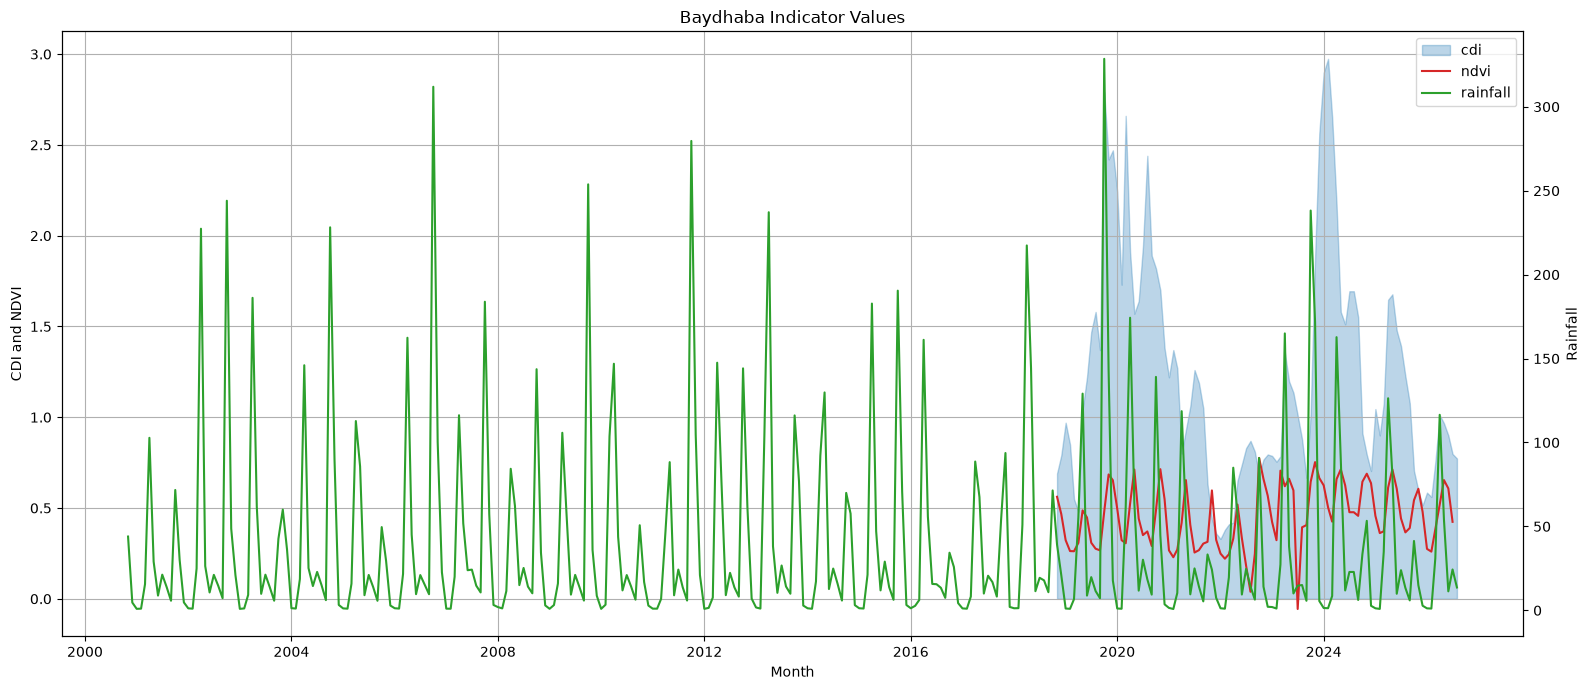

In [41]:
chart_data = df_ind_bai.drop(columns=["district", "region"]).copy()
chart_data = chart_data.loc[chart_data["indicator"] != "market"]
chart_data["month"] = pd.to_datetime(chart_data["month"], errors="coerce")
chart_data["value"] = pd.to_numeric(chart_data["value"], errors="coerce")
chart_data = chart_data.dropna(subset=["month", "value"])
chart_data = chart_data.loc[
    ~((chart_data["indicator"] == "ndvi") & (chart_data["value"] == 13.637))
]

fig, ax_left = plt.subplots(figsize=(16, 7))
ax_right = ax_left.twinx()

cdi_data = chart_data.loc[chart_data["indicator"] == "cdi"].sort_values("month")
ax_left.fill_between(
    cdi_data["month"],
    cdi_data["value"],
    color="tab:blue",
    alpha=0.3,
    label="cdi",
)

ndvi_data = chart_data.loc[chart_data["indicator"] == "ndvi"].sort_values("month")
ax_left.plot(
    ndvi_data["month"],
    ndvi_data["value"],
    color="tab:red",
    label="ndvi",
)

rainfall_data = chart_data.loc[chart_data["indicator"] == "rainfall"].sort_values("month")
ax_right.plot(
    rainfall_data["month"],
    rainfall_data["value"],
    color="tab:green",
    label="rainfall",
)

ax_left.set_title("Baydhaba Indicator Values")
ax_left.set_xlabel("Month")
ax_left.set_ylabel("CDI and NDVI")
ax_right.set_ylabel("Rainfall")
ax_left.grid(True)

left_lines, left_labels = ax_left.get_legend_handles_labels()
right_lines, right_labels = ax_right.get_legend_handles_labels()
ax_left.legend(left_lines + right_lines, left_labels + right_labels)

plt.tight_layout()
plt.show()

In [42]:
df_ind_bai.loc[df_ind_bai["indicator"] == "ndvi"].assign(
    value=lambda dataframe: pd.to_numeric(dataframe["value"], errors="coerce")
).sort_values("value", ascending=False)

,month,value,district,indicator,region
20775,2026-08-01,13.637,Baydhaba,ndvi,Bay
1719,2022-10-01,0.776,Baydhaba,ndvi,Bay
9696,2023-11-01,0.753,Baydhaba,ndvi,Bay
1352,2020-11-01,0.714,Baydhaba,ndvi,Bay
9984,2024-05-01,0.713,Baydhaba,ndvi,Bay
...,...,...,...,...,...
947,2021-02-01,0.229,Baydhaba,ndvi,Bay
1591,2022-02-01,0.221,Baydhaba,ndvi,Bay
1671,2022-07-01,0.182,Baydhaba,ndvi,Bay
1687,2022-08-01,0.039,Baydhaba,ndvi,Bay


In [43]:
error_df

,original_date,original_time,station_id,sensor_id,sensor_meaning,value
0,'2025/06/16',140000,'BAIDOA_MOH','00AT','Air Temperature','---'
1,'2025/06/16',130000,'BAIDOA_MOH','00AT','Air Temperature','---'
2,'2025/06/16',140000,'BAIDOA_MOH','00RH','Relative Humidity','---'
3,'2025/06/16',130000,'BAIDOA_MOH','00RH','Relative Humidity','---'
4,'2025/06/16',140000,'BAIDOA_MOH','00AP','Atmospheric Pressure','---'
...,...,...,...,...,...,...
1392,'2025/08/20','050000','MOHADM_AFG','SOLR','Solar Radiation','---'
1393,'2025/08/20','040000','MOHADM_AFG','SOLR','Solar Radiation','---'
1394,'2025/08/20','030000','MOHADM_AFG','SOLR','Solar Radiation','---'
1395,'2025/08/20','020000','MOHADM_AFG','SOLR','Solar Radiation','---'


In [44]:
error_df.groupby('sensor_meaning').size()

sensor_meaning
'Air Temperature'         178
'Atmospheric Pressure'    178
'Dew Point'               178
'Rainfall'                173
'Relative Humidity'       178
'Solar Radiation'         166
'Wind Direction'          173
'Wind Speed'              173
dtype: int64

In [45]:
error_df.groupby('value').size()

value
'---'      1356
-999.0       34
-999.00       7
dtype: int64

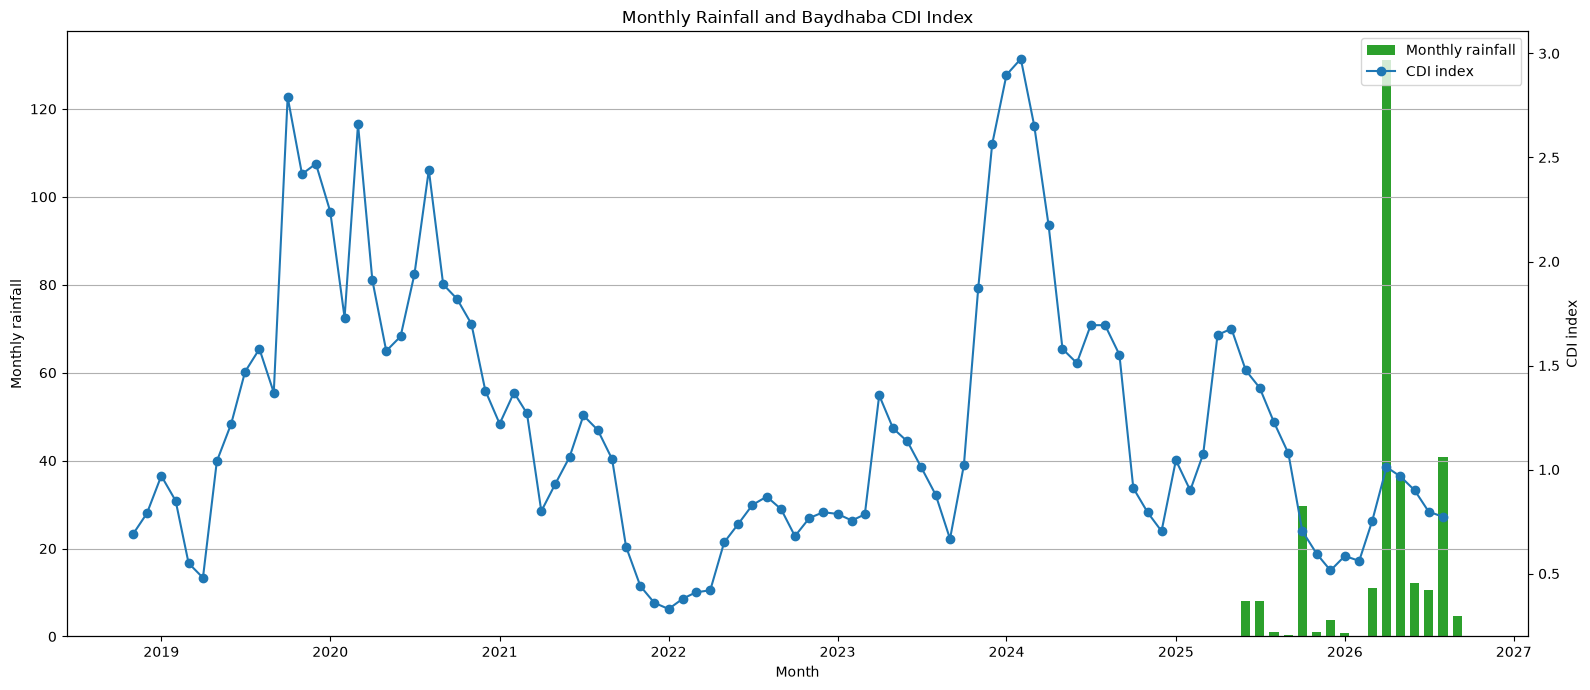

In [46]:
monthly_rainfall = (
    df_BAIDOA_MOH_wndw_daily.assign(
        year_month=lambda dataframe: pd.to_datetime(
            dataframe["original_date"], errors="coerce"
        ).dt.to_period("M").dt.to_timestamp()
    )
    .groupby("year_month", as_index=False)["RAIN"]
    .sum()
)

monthly_cdi = (
    df_cdi_bai.assign(
        year_month=lambda dataframe: pd.to_datetime(
            {
                "year": pd.to_numeric(dataframe["year"], errors="coerce"),
                "month": pd.to_numeric(dataframe["month"], errors="coerce"),
                "day": 1,
            },
            errors="coerce",
        ),
        value=lambda dataframe: pd.to_numeric(dataframe["value"], errors="coerce"),
    )
    .dropna(subset=["year_month", "value"])
    .groupby("year_month", as_index=False)["value"]
    .mean()
    .rename(columns={"value": "cdi_index"})
)

monthly_rainfall_cdi = monthly_rainfall.merge(
    monthly_cdi,
    on="year_month",
    how="outer",
).sort_values("year_month")

fig, ax_left = plt.subplots(figsize=(16, 7))
ax_right = ax_left.twinx()

ax_left.bar(
    monthly_rainfall_cdi["year_month"],
    monthly_rainfall_cdi["RAIN"],
    width=20,
    color="tab:green",
    label="Monthly rainfall",
)
ax_right.plot(
    monthly_rainfall_cdi["year_month"],
    monthly_rainfall_cdi["cdi_index"],
    color="tab:blue",
    marker="o",
    label="CDI index",
)

ax_left.set_title("Monthly Rainfall and Baydhaba CDI Index")
ax_left.set_xlabel("Month")
ax_left.set_ylabel("Monthly rainfall")
ax_right.set_ylabel("CDI index")
ax_left.grid(True, axis="y")

left_lines, left_labels = ax_left.get_legend_handles_labels()
right_lines, right_labels = ax_right.get_legend_handles_labels()
ax_left.legend(left_lines + right_lines, left_labels + right_labels)

plt.tight_layout()
plt.show()

In [47]:
df_BAIDOA_MOH_wndw.info()

<class 'pandas.DataFrame'>
RangeIndex: 10727 entries, 0 to 10726
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   original_date  10727 non-null  datetime64[us]
 1   original_time  10727 non-null  str           
 2   00AP           10726 non-null  float64       
 3   00AT           10726 non-null  float64       
 4   00DP           10726 non-null  float64       
 5   00RH           10726 non-null  float64       
 6   RAIN           10727 non-null  float64       
 7   SOLR           10727 non-null  float64       
 8   WNDW           10727 non-null  float64       
dtypes: datetime64[us](1), float64(7), str(1)
memory usage: 754.4 KB


In [48]:
df_ind_bai

,month,value,district,indicator,region
7,2018-11-01,0.690,Baydhaba,cdi,Bay
23,2018-12-01,0.790,Baydhaba,cdi,Bay
39,2019-01-01,0.970,Baydhaba,cdi,Bay
55,2019-02-01,0.850,Baydhaba,cdi,Bay
71,2019-03-01,0.550,Baydhaba,cdi,Bay
...,...,...,...,...,...
20712,2026-07-01,0.798,Baydhaba,cdi,Bay
20728,2026-07-01,0.424,Baydhaba,ndvi,Bay
20744,2026-08-01,13.637,Baydhaba,rainfall,Bay
20760,2026-08-01,0.773,Baydhaba,cdi,Bay


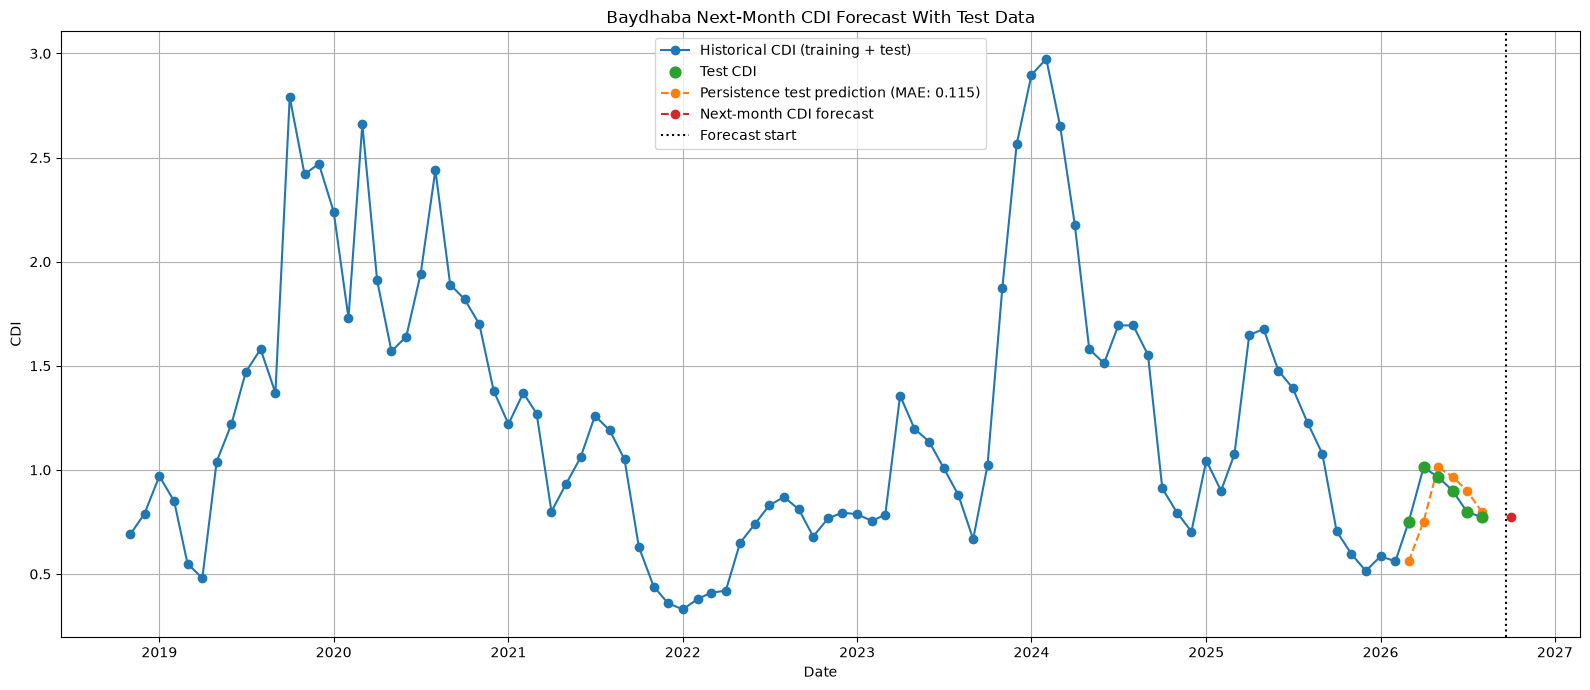

,month,predicted_cdi
0,2026-10-01,0.773


In [49]:
last_weather_date = pd.to_datetime(
    df_BAIDOA_MOH_wndw["original_date"], errors="coerce"
).max().normalize()

cdi_data = (
    df_ind_bai.loc[df_ind_bai["indicator"] == "cdi"]
    .assign(
        month=lambda dataframe: pd.to_datetime(
            dataframe["month"], errors="coerce"
        ).dt.to_period("M").dt.to_timestamp(),
        cdi=lambda dataframe: pd.to_numeric(dataframe["value"], errors="coerce"),
    )
    .dropna(subset=["month", "cdi"])
    .groupby("month", as_index=False)["cdi"]
    .mean()
    .sort_values("month")
)

historical_cdi = cdi_data.loc[cdi_data["month"] <= last_weather_date].copy()
test_months = 6
training_cdi = historical_cdi.iloc[:-test_months].copy()
test_cdi = historical_cdi.iloc[-test_months:].copy()

persistence_predictions = []
trend_predictions = []
for test_position in range(len(training_cdi), len(historical_cdi)):
    prior_values = historical_cdi.iloc[:test_position]["cdi"]
    persistence_predictions.append(prior_values.iloc[-1])
    recent_changes = prior_values.diff().dropna().tail(3)
    trend_predictions.append(prior_values.iloc[-1] + recent_changes.mean())

test_cdi["persistence_prediction"] = persistence_predictions
test_cdi["trend_prediction"] = trend_predictions
persistence_mae = (
    test_cdi["cdi"] - test_cdi["persistence_prediction"]
).abs().mean()
trend_mae = (test_cdi["cdi"] - test_cdi["trend_prediction"]).abs().mean()

last_cdi = historical_cdi["cdi"].iloc[-1]
if trend_mae < persistence_mae:
    selected_model = "Recent trend"
    test_cdi["predicted_cdi"] = test_cdi["trend_prediction"]
    monthly_change = historical_cdi["cdi"].diff().dropna().tail(3).mean()
    next_month_prediction = last_cdi + monthly_change
else:
    selected_model = "Persistence"
    test_cdi["predicted_cdi"] = test_cdi["persistence_prediction"]
    next_month_prediction = last_cdi

next_month = (last_weather_date.to_period("M") + 1).to_timestamp()
cdi_forecast = pd.DataFrame(
    {"month": [next_month], "predicted_cdi": [next_month_prediction]}
)

selected_mae = min(persistence_mae, trend_mae)

fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(
    historical_cdi["month"],
    historical_cdi["cdi"],
    color="tab:blue",
    marker="o",
    label="Historical CDI (training + test)",
)
ax.scatter(
    test_cdi["month"],
    test_cdi["cdi"],
    color="tab:green",
    s=60,
    zorder=3,
    label="Test CDI",
)
ax.plot(
    test_cdi["month"],
    test_cdi["predicted_cdi"],
    color="tab:orange",
    linestyle="--",
    marker="o",
    label=f"{selected_model} test prediction (MAE: {selected_mae:.3f})",
)
ax.plot(
    cdi_forecast["month"],
    cdi_forecast["predicted_cdi"],
    color="tab:red",
    linestyle="--",
    marker="o",
    label="Next-month CDI forecast",
)
ax.axvline(last_weather_date, color="black", linestyle=":", label="Forecast start")
ax.set_title("Baydhaba Next-Month CDI Forecast With Test Data")
ax.set_xlabel("Date")
ax.set_ylabel("CDI")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

cdi_forecast

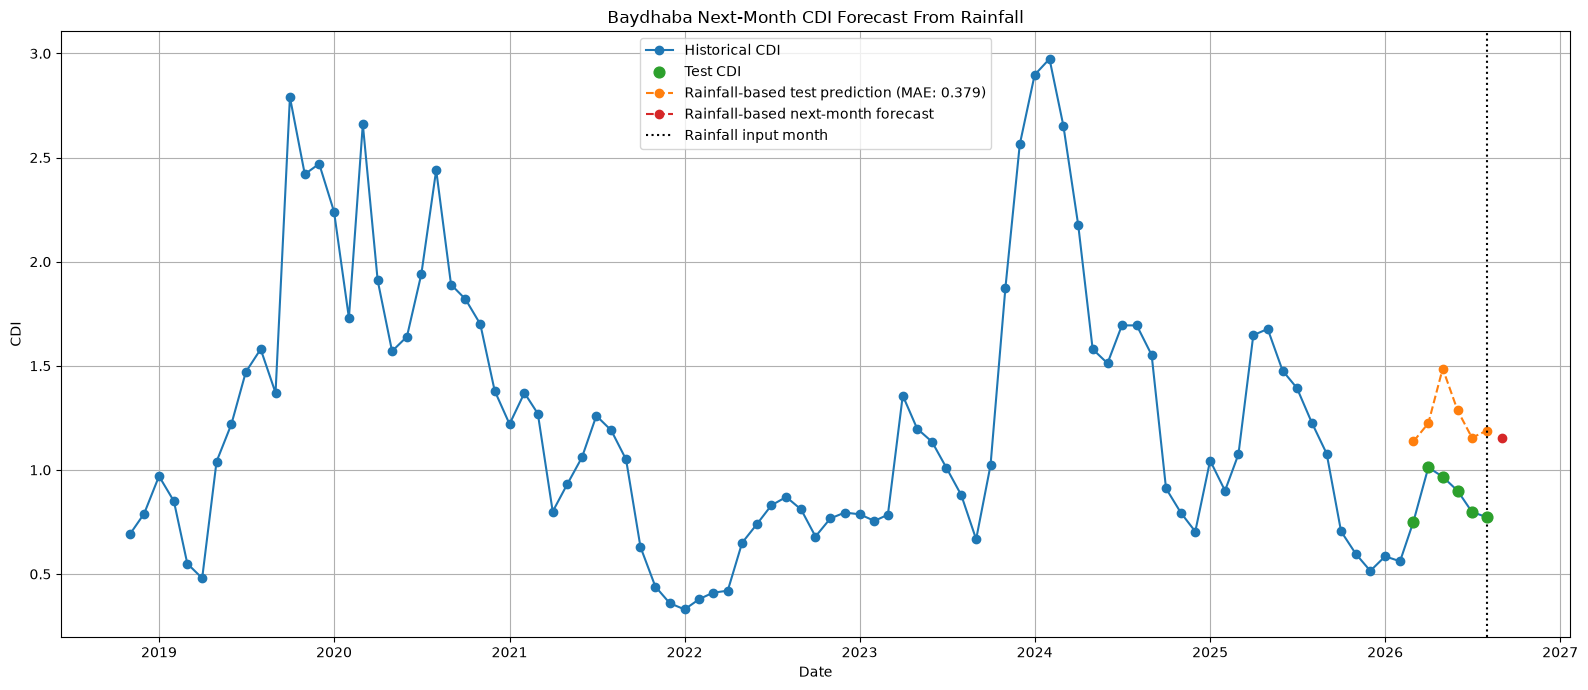

,month,rainfall_used,predicted_cdi
0,2026-09-01,13.637,1.151619


In [50]:
indicator_data = (
    df_ind_bai.loc[df_ind_bai["indicator"].isin(["cdi", "rainfall"])]
    .assign(
        month=lambda dataframe: pd.to_datetime(
            dataframe["month"], errors="coerce"
        ).dt.to_period("M").dt.to_timestamp(),
        value=lambda dataframe: pd.to_numeric(dataframe["value"], errors="coerce"),
    )
    .dropna(subset=["month", "value"])
    .pivot_table(
        index="month",
        columns="indicator",
        values="value",
        aggfunc="mean",
    )
    .reset_index()
    .sort_values("month")
)

cdi_data = indicator_data[["month", "cdi"]].dropna().copy()
rainfall_to_cdi = (
    indicator_data[["month", "rainfall"]]
    .dropna()
    .assign(target_month=lambda dataframe: dataframe["month"] + pd.offsets.MonthBegin(1))
    .merge(
        cdi_data.rename(columns={"month": "target_month", "cdi": "target_cdi"}),
        on="target_month",
        how="inner",
    )
    .sort_values("target_month")
)

test_months = 6
training_data = rainfall_to_cdi.iloc[:-test_months].copy()
test_data = rainfall_to_cdi.iloc[-test_months:].copy()

predicted_test_values = []
for test_position in range(len(training_data), len(rainfall_to_cdi)):
    prior_data = rainfall_to_cdi.iloc[:test_position]
    slope, intercept = np.polyfit(prior_data["rainfall"], prior_data["target_cdi"], 1)
    predicted_test_values.append(
        slope * rainfall_to_cdi.iloc[test_position]["rainfall"] + intercept
    )

test_data["predicted_cdi"] = predicted_test_values
test_mae = (test_data["target_cdi"] - test_data["predicted_cdi"]).abs().mean()

slope, intercept = np.polyfit(
    rainfall_to_cdi["rainfall"],
    rainfall_to_cdi["target_cdi"],
    1,
)
latest_rainfall = indicator_data.dropna(subset=["rainfall"]).iloc[-1]
next_month = latest_rainfall["month"] + pd.offsets.MonthBegin(1)
next_month_prediction = slope * latest_rainfall["rainfall"] + intercept
rainfall_cdi_forecast = pd.DataFrame(
    {
        "month": [next_month],
        "rainfall_used": [latest_rainfall["rainfall"]],
        "predicted_cdi": [next_month_prediction],
    }
)

fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(
    cdi_data["month"],
    cdi_data["cdi"],
    color="tab:blue",
    marker="o",
    label="Historical CDI",
)
ax.scatter(
    test_data["target_month"],
    test_data["target_cdi"],
    color="tab:green",
    s=60,
    zorder=3,
    label="Test CDI",
)
ax.plot(
    test_data["target_month"],
    test_data["predicted_cdi"],
    color="tab:orange",
    linestyle="--",
    marker="o",
    label=f"Rainfall-based test prediction (MAE: {test_mae:.3f})",
)
ax.plot(
    rainfall_cdi_forecast["month"],
    rainfall_cdi_forecast["predicted_cdi"],
    color="tab:red",
    linestyle="--",
    marker="o",
    label="Rainfall-based next-month forecast",
)
ax.axvline(latest_rainfall["month"], color="black", linestyle=":", label="Rainfall input month")
ax.set_title("Baydhaba Next-Month CDI Forecast From Rainfall")
ax.set_xlabel("Date")
ax.set_ylabel("CDI")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

rainfall_cdi_forecast

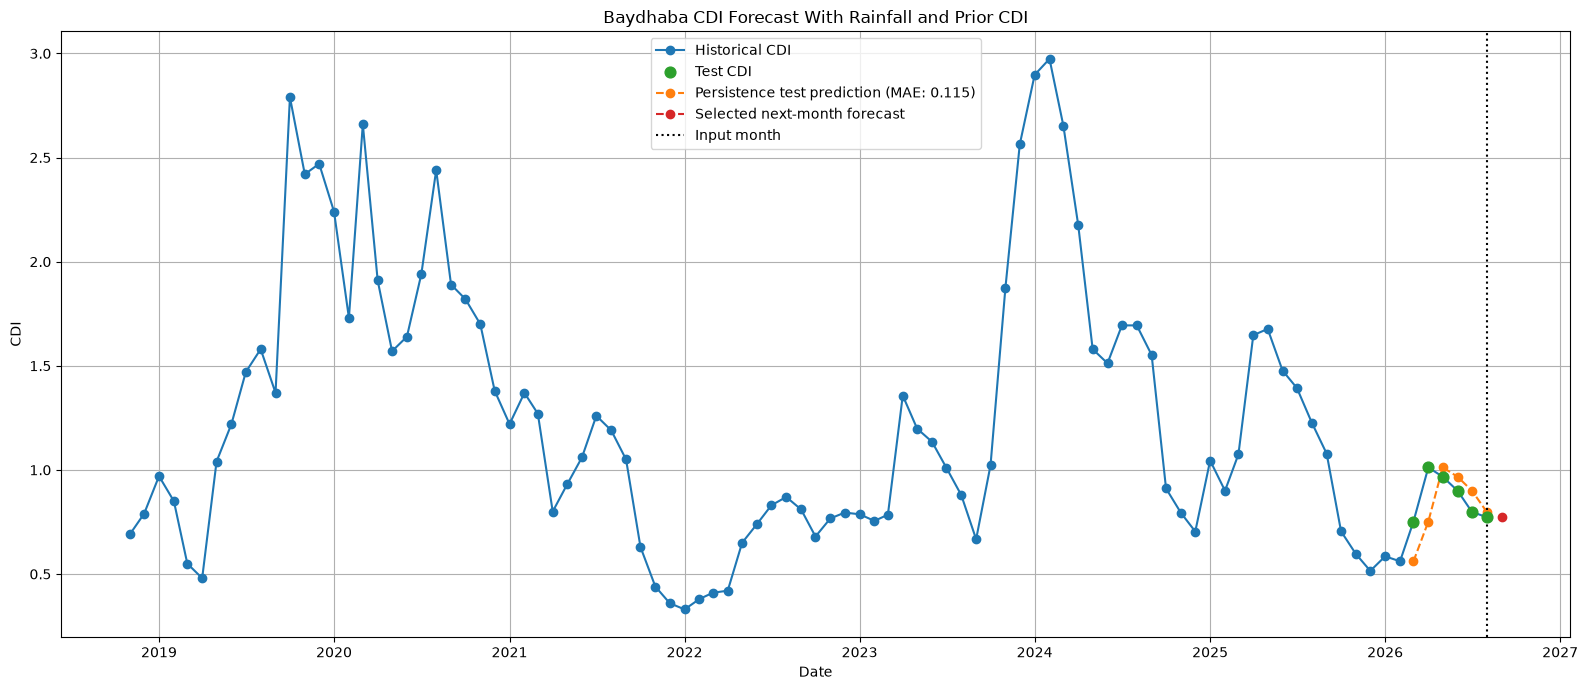

,month,rainfall_used,predicted_cdi,selected_model,test_mae
0,2026-09-01,13.637,0.773,Persistence,0.115


In [51]:
indicator_data = (
    df_ind_bai.loc[df_ind_bai["indicator"].isin(["cdi", "rainfall"])]
    .assign(
        month=lambda dataframe: pd.to_datetime(
            dataframe["month"], errors="coerce"
        ).dt.to_period("M").dt.to_timestamp(),
        value=lambda dataframe: pd.to_numeric(dataframe["value"], errors="coerce"),
    )
    .dropna(subset=["month", "value"])
    .pivot_table(
        index="month",
        columns="indicator",
        values="value",
        aggfunc="mean",
    )
    .reset_index()
    .sort_values("month")
)

cdi_data = indicator_data[["month", "cdi"]].dropna().copy()
predictor_data = (
    indicator_data[["month", "cdi", "rainfall"]]
    .dropna()
    .assign(target_month=lambda dataframe: dataframe["month"] + pd.offsets.MonthBegin(1))
    .merge(
        cdi_data.rename(columns={"month": "target_month", "cdi": "target_cdi"}),
        on="target_month",
        how="inner",
    )
    .sort_values("target_month")
)
predictor_data["log_rainfall"] = np.log1p(predictor_data["rainfall"])

test_months = 6
training_data = predictor_data.iloc[:-test_months].copy()
test_data = predictor_data.iloc[-test_months:].copy()

persistence_predictions = []
rainfall_predictions = []
combined_predictions = []
for test_position in range(len(training_data), len(predictor_data)):
    prior_data = predictor_data.iloc[:test_position]
    test_row = predictor_data.iloc[test_position]

    rainfall_slope, rainfall_intercept = np.polyfit(
        prior_data["log_rainfall"],
        prior_data["target_cdi"],
        1,
    )
    combined_matrix = np.column_stack(
        [
            np.ones(len(prior_data)),
            prior_data["cdi"],
            prior_data["log_rainfall"],
        ]
    )
    combined_coefficients = np.linalg.lstsq(
        combined_matrix,
        prior_data["target_cdi"],
        rcond=None,
    )[0]

    persistence_predictions.append(test_row["cdi"])
    rainfall_predictions.append(
        rainfall_intercept + rainfall_slope * test_row["log_rainfall"]
    )
    combined_predictions.append(
        combined_coefficients[0]
        + combined_coefficients[1] * test_row["cdi"]
        + combined_coefficients[2] * test_row["log_rainfall"]
    )

test_data["persistence_prediction"] = persistence_predictions
test_data["rainfall_prediction"] = rainfall_predictions
test_data["combined_prediction"] = combined_predictions

model_mae = {
    "Persistence": (test_data["target_cdi"] - test_data["persistence_prediction"])
    .abs()
    .mean(),
    "Rainfall only": (test_data["target_cdi"] - test_data["rainfall_prediction"])
    .abs()
    .mean(),
    "CDI and rainfall": (test_data["target_cdi"] - test_data["combined_prediction"])
    .abs()
    .mean(),
}
selected_model = min(model_mae, key=model_mae.get)
prediction_column = {
    "Persistence": "persistence_prediction",
    "Rainfall only": "rainfall_prediction",
    "CDI and rainfall": "combined_prediction",
}[selected_model]
test_data["predicted_cdi"] = test_data[prediction_column]

latest_predictors = indicator_data.dropna(subset=["cdi", "rainfall"]).iloc[-1]
if selected_model == "Persistence":
    next_month_prediction = latest_predictors["cdi"]
elif selected_model == "Rainfall only":
    rainfall_slope, rainfall_intercept = np.polyfit(
        predictor_data["log_rainfall"],
        predictor_data["target_cdi"],
        1,
    )
    next_month_prediction = (
        rainfall_intercept + rainfall_slope * np.log1p(latest_predictors["rainfall"])
    )
else:
    combined_matrix = np.column_stack(
        [
            np.ones(len(predictor_data)),
            predictor_data["cdi"],
            predictor_data["log_rainfall"],
        ]
    )
    combined_coefficients = np.linalg.lstsq(
        combined_matrix,
        predictor_data["target_cdi"],
        rcond=None,
    )[0]
    next_month_prediction = (
        combined_coefficients[0]
        + combined_coefficients[1] * latest_predictors["cdi"]
        + combined_coefficients[2] * np.log1p(latest_predictors["rainfall"])
    )

next_month = latest_predictors["month"] + pd.offsets.MonthBegin(1)
improved_cdi_forecast = pd.DataFrame(
    {
        "month": [next_month],
        "rainfall_used": [latest_predictors["rainfall"]],
        "predicted_cdi": [next_month_prediction],
        "selected_model": [selected_model],
        "test_mae": [model_mae[selected_model]],
    }
)

fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(
    cdi_data["month"],
    cdi_data["cdi"],
    color="tab:blue",
    marker="o",
    label="Historical CDI",
)
ax.scatter(
    test_data["target_month"],
    test_data["target_cdi"],
    color="tab:green",
    s=60,
    zorder=3,
    label="Test CDI",
)
ax.plot(
    test_data["target_month"],
    test_data["predicted_cdi"],
    color="tab:orange",
    linestyle="--",
    marker="o",
    label=f"{selected_model} test prediction (MAE: {model_mae[selected_model]:.3f})",
)
ax.plot(
    improved_cdi_forecast["month"],
    improved_cdi_forecast["predicted_cdi"],
    color="tab:red",
    linestyle="--",
    marker="o",
    label="Selected next-month forecast",
)
ax.axvline(latest_predictors["month"], color="black", linestyle=":", label="Input month")
ax.set_title("Baydhaba CDI Forecast With Rainfall and Prior CDI")
ax.set_xlabel("Date")
ax.set_ylabel("CDI")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

improved_cdi_forecast